<a href="https://colab.research.google.com/github/KazterING/ABP5/blob/main/ABP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# CELDA 1: IMPORTACIÓN DE LIBRERÍAS
# =========================

import warnings
warnings.filterwarnings("ignore")

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Configuración visual
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


In [3]:
# =========================
# CELDA 2: GENERACIÓN DEL DATASET SINTÉTICO
# =========================

np.random.seed(42)

n = 1000

edad = np.random.randint(18, 70, n)
ingreso_anual = np.random.normal(750000, 180000, n).clip(250000, 1500000)
tiempo_en_sitio = np.random.normal(12, 4, n).clip(1, 30)
paginas_vistas = np.random.normal(25, 10, n).clip(3, 80).astype(int)
membresia_anios = np.random.normal(3, 1.5, n).clip(0, 10)
compras_previas = np.random.poisson(8, n)
uso_app = np.random.normal(35, 12, n).clip(5, 90)
descuento_promedio = np.random.normal(12, 5, n).clip(0, 40)

genero = np.random.choice(["Masculino", "Femenino", "Otro"], size=n, p=[0.47, 0.47, 0.06])
dispositivo = np.random.choice(["Mobile", "Desktop", "Tablet"], size=n, p=[0.6, 0.3, 0.1])
region = np.random.choice(["Norte", "Centro", "Sur"], size=n, p=[0.25, 0.5, 0.25])
cliente_premium = np.random.choice(["Sí", "No"], size=n, p=[0.35, 0.65])

# Variable objetivo: gasto promedio
gasto_promedio = (
    ingreso_anual * 0.00045
    + tiempo_en_sitio * 8
    + paginas_vistas * 2.5
    + membresia_anios * 18
    + compras_previas * 6
    + uso_app * 1.8
    - descuento_promedio * 1.2
    + np.where(cliente_premium == "Sí", 55, 0)
    + np.where(dispositivo == "Mobile", 12, 0)
    + np.where(region == "Centro", 8, 0)
    + np.random.normal(0, 35, n)
)

df = pd.DataFrame({
    "edad": edad,
    "ingreso_anual": ingreso_anual,
    "tiempo_en_sitio": tiempo_en_sitio,
    "paginas_vistas": paginas_vistas,
    "membresia_anios": membresia_anios,
    "compras_previas": compras_previas,
    "uso_app": uso_app,
    "descuento_promedio": descuento_promedio,
    "genero": genero,
    "dispositivo": dispositivo,
    "region": region,
    "cliente_premium": cliente_premium,
    "gasto_promedio": gasto_promedio
})

print("✅ Dataset sintético generado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

✅ Dataset sintético generado correctamente.
Filas: 1000
Columnas: 13


In [4]:
# =========================
# CELDA 3: PRIMERA VISTA DEL DATASET
# =========================

df.head()

,edad,ingreso_anual,tiempo_en_sitio,paginas_vistas,membresia_anios,compras_previas,uso_app,descuento_promedio,genero,dispositivo,region,cliente_premium,gasto_promedio
0,56,460839.662354,18.907855,44,2.458034,7,49.112132,14.618639,Femenino,Desktop,Sur,No,572.856503
1,69,786623.454456,10.401455,17,2.903724,9,48.617223,15.027720,Otro,Mobile,Sur,Sí,759.374320
2,46,613856.865849,12.898739,19,1.484103,9,40.161716,9.826325,Femenino,Tablet,Norte,No,516.646436
3,32,493994.332272,15.730363,33,2.227172,10,41.102424,4.524012,Otro,Mobile,Centro,No,611.555801
4,60,633616.880836,6.326537,21,5.295293,4,40.071543,12.040334,Femenino,Mobile,Norte,No,585.791447


In [5]:
# =========================
# CELDA 4: ESTRUCTURA GENERAL
# =========================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edad                1000 non-null   int64  
 1   ingreso_anual       1000 non-null   float64
 2   tiempo_en_sitio     1000 non-null   float64
 3   paginas_vistas      1000 non-null   int64  
 4   membresia_anios     1000 non-null   float64
 5   compras_previas     1000 non-null   int64  
 6   uso_app             1000 non-null   float64
 7   descuento_promedio  1000 non-null   float64
 8   genero              1000 non-null   object 
 9   dispositivo         1000 non-null   object 
 10  region              1000 non-null   object 
 11  cliente_premium     1000 non-null   object 
 12  gasto_promedio      1000 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.7+ KB


In [6]:
# =========================
# CELDA 5: INTRODUCCIÓN DE NULOS Y OUTLIERS
# =========================

df_procesado = df.copy()

# Introducir nulos en columnas numéricas
for col in ["ingreso_anual", "tiempo_en_sitio", "uso_app"]:
    df_procesado.loc[df_procesado.sample(frac=0.05).index, col] = np.nan

# Introducir nulos en categóricas
for col in ["genero", "dispositivo"]:
    df_procesado.loc[df_procesado.sample(frac=0.03).index, col] = np.nan

# Introducir outliers en ingreso
outliers_idx = df_procesado.sample(frac=0.02).index
df_procesado.loc[outliers_idx, "ingreso_anual"] *= 3

print("✅ Nulos y outliers introducidos.")

✅ Nulos y outliers introducidos.


In [7]:
# =========================
# CELDA 6: ANÁLISIS DE VALORES NULOS
# =========================

df_procesado.isnull().sum()

,0
edad,0
ingreso_anual,50
tiempo_en_sitio,50
paginas_vistas,0
membresia_anios,0
compras_previas,0
uso_app,50
descuento_promedio,0
genero,30
dispositivo,30


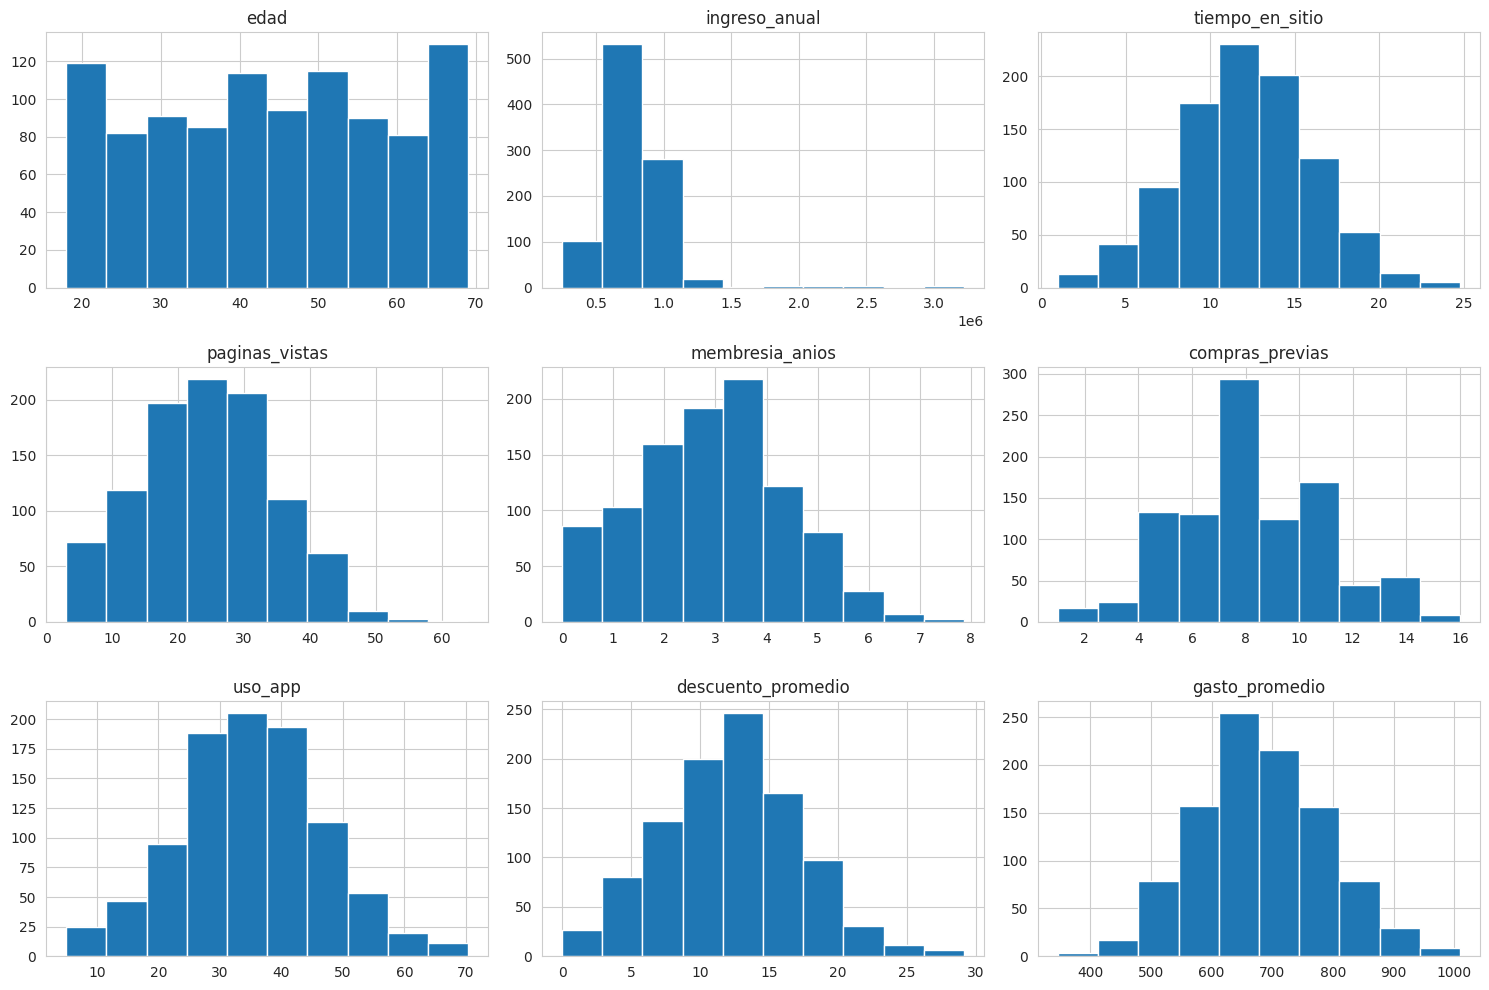

In [8]:
# =========================
# CELDA 7: DISTRIBUCIÓN DE VARIABLES
# =========================

df_procesado.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [9]:
# =========================
# CELDA 8: DEFINICIÓN DE VARIABLES
# =========================

X = df_procesado.drop("gasto_promedio", axis=1)
y = df_procesado["gasto_promedio"]

print("Variables X:", X.shape)
print("Variable y:", y.shape)

Variables X: (1000, 12)
Variable y: (1000,)


In [10]:
# =========================
# CELDA 9: DIVISIÓN TRAIN / TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (800, 12)
Test: (200, 12)


In [11]:
# =========================
# CELDA 10: PREPROCESAMIENTO
# =========================

# Columnas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Pipeline numérico
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("✅ Pipeline de preprocesamiento listo.")

✅ Pipeline de preprocesamiento listo.


In [12]:
# =========================
# CELDA 11: MODELO REGRESIÓN LINEAL
# =========================

modelo_lineal = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

modelo_lineal.fit(X_train, y_train)

print("✅ Modelo de regresión lineal entrenado.")

✅ Modelo de regresión lineal entrenado.


In [13]:
# =========================
# CELDA 12: PREDICCIONES
# =========================

y_pred_train = modelo_lineal.predict(X_train)
y_pred_test = modelo_lineal.predict(X_test)

In [14]:
# =========================
# CELDA 13: MÉTRICAS
# =========================

def evaluar_modelo(y_real, y_pred, nombre="Modelo"):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    print(f"\n🔹 {nombre}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

# Evaluación
evaluar_modelo(y_train, y_pred_train, "Train - Regresión Lineal")
evaluar_modelo(y_test, y_pred_test, "Test - Regresión Lineal")


🔹 Train - Regresión Lineal
MAE:  56.85
RMSE: 75.24
R²:   0.5099

🔹 Test - Regresión Lineal
MAE:  52.08
RMSE: 65.53
R²:   0.5803


In [15]:
# =========================
# CELDA 14: VALIDACIÓN CRUZADA
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    modelo_lineal,
    X,
    y,
    scoring="r2",
    cv=kf
)

print("R² por fold:", scores)
print("R² promedio:", scores.mean())

R² por fold: [0.58034548 0.22352294 0.59659936 0.45267884 0.47833737]
R² promedio: 0.46629679752259195


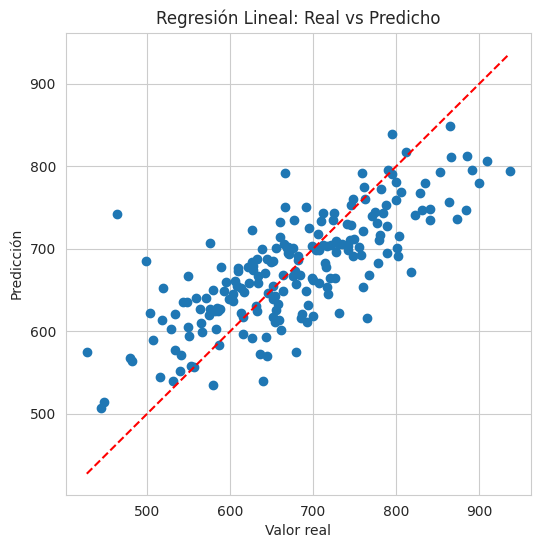

In [16]:
# =========================
# CELDA 15: VISUALIZACIÓN
# =========================

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión Lineal: Real vs Predicho")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [17]:
# =========================
# CELDA 16: REGRESIÓN POLINÓMICA
# =========================

modelo_polinomico = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

modelo_polinomico.fit(X_train, y_train)

print("✅ Modelo polinómico entrenado.")

✅ Modelo polinómico entrenado.


In [18]:
# =========================
# CELDA 17: PREDICCIONES POLINÓMICAS
# =========================

y_pred_train_poly = modelo_polinomico.predict(X_train)
y_pred_test_poly = modelo_polinomico.predict(X_test)

In [19]:
# =========================
# CELDA 18: MÉTRICAS POLINÓMICO
# =========================

evaluar_modelo(y_train, y_pred_train_poly, "Train - Polinómico")
evaluar_modelo(y_test, y_pred_test_poly, "Test - Polinómico")


🔹 Train - Polinómico
MAE:  33.37
RMSE: 45.22
R²:   0.8229

🔹 Test - Polinómico
MAE:  36.55
RMSE: 50.58
R²:   0.7500


In [20]:
# =========================
# CELDA 19: COMPARACIÓN LINEAL VS POLINÓMICO
# =========================

print("LINEAL:")
evaluar_modelo(y_test, y_pred_test, "Test - Lineal")

print("\nPOLINÓMICO:")
evaluar_modelo(y_test, y_pred_test_poly, "Test - Polinómico")

LINEAL:

🔹 Test - Lineal
MAE:  52.08
RMSE: 65.53
R²:   0.5803

POLINÓMICO:

🔹 Test - Polinómico
MAE:  36.55
RMSE: 50.58
R²:   0.7500


In [21]:
# =========================
# CELDA 20: CREAR CLASES DE GASTO
# =========================

# Convertimos gasto en categorías
y_clasificacion = pd.qcut(y, q=3, labels=["Bajo", "Medio", "Alto"])

In [22]:
# =========================
# CELDA 21: SPLIT CLASIFICACIÓN
# =========================

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clasificacion, test_size=0.2, random_state=42
)

In [23]:
# =========================
# CELDA 22: KNN CLASIFICADOR
# =========================

modelo_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

modelo_knn.fit(X_train_c, y_train_c)

print("✅ Modelo KNN entrenado.")

✅ Modelo KNN entrenado.


In [24]:
# =========================
# CELDA 23: EVALUACIÓN KNN
# =========================

from sklearn.metrics import accuracy_score

y_pred_knn = modelo_knn.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_knn)

print(f"Accuracy KNN: {accuracy:.2f}")

Accuracy KNN: 0.54


In [25]:
# =========================
# CELDA 24: TABLA COMPARATIVA INICIAL
# =========================

resultados = []

def guardar_resultados(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

guardar_resultados("Regresión Lineal", y_test, y_pred_test)
guardar_resultados("Regresión Polinómica", y_test, y_pred_test_poly)

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,52.08,65.53,0.5803
1,Regresión Polinómica,36.55,50.58,0.7500


In [26]:
# =========================
# CELDA 25: MODELO RIDGE
# =========================

modelo_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

modelo_ridge.fit(X_train, y_train)

y_pred_ridge = modelo_ridge.predict(X_test)

evaluar_modelo(y_test, y_pred_ridge, "Test - Ridge")


🔹 Test - Ridge
MAE:  52.10
RMSE: 65.55
R²:   0.5802


In [27]:
# =========================
# CELDA 26: MODELO LASSO
# =========================

modelo_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

modelo_lasso.fit(X_train, y_train)

y_pred_lasso = modelo_lasso.predict(X_test)

evaluar_modelo(y_test, y_pred_lasso, "Test - Lasso")


🔹 Test - Lasso
MAE:  52.05
RMSE: 65.50
R²:   0.5808


In [28]:
# =========================
# CELDA 27: ACTUALIZAR TABLA DE RESULTADOS
# =========================

guardar_resultados("Ridge", y_test, y_pred_ridge)
guardar_resultados("Lasso", y_test, y_pred_lasso)

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,52.08,65.53,0.5803
1,Regresión Polinómica,36.55,50.58,0.7500
2,Ridge,52.10,65.55,0.5802
3,Lasso,52.05,65.50,0.5808


In [29]:
# =========================
# CELDA 28: GRIDSEARCHCV PARA RIDGE
# =========================

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

grid_ridge = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    param_grid=param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Mejor alpha para Ridge:", grid_ridge.best_params_)
print("Mejor R² CV Ridge:", grid_ridge.best_score_)

Mejor alpha para Ridge: {'model__alpha': 50.0}
Mejor R² CV Ridge: 0.47161050200693583


In [30]:
# =========================
# CELDA 29: EVALUAR MEJOR RIDGE
# =========================

mejor_ridge = grid_ridge.best_estimator_
y_pred_mejor_ridge = mejor_ridge.predict(X_test)

evaluar_modelo(y_test, y_pred_mejor_ridge, "Test - Mejor Ridge")


🔹 Test - Mejor Ridge
MAE:  52.99
RMSE: 66.37
R²:   0.5695


In [31]:
# =========================
# CELDA 30: GRADIENT BOOSTING REGRESSOR
# =========================

modelo_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

modelo_gb.fit(X_train, y_train)

y_pred_gb = modelo_gb.predict(X_test)

evaluar_modelo(y_test, y_pred_gb, "Test - Gradient Boosting")


🔹 Test - Gradient Boosting
MAE:  36.34
RMSE: 50.22
R²:   0.7536


In [32]:
# =========================
# CELDA 31: OPTIMIZACIÓN DE GRADIENT BOOSTING
# =========================

param_grid_gb = {
    "model__n_estimators": [50, 100, 150],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4]
}

grid_gb = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    param_grid=param_grid_gb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Mejores parámetros GB:", grid_gb.best_params_)
print("Mejor R² CV GB:", grid_gb.best_score_)

Mejores parámetros GB: {'model__learning_rate': 0.2, 'model__max_depth': 2, 'model__n_estimators': 150}
Mejor R² CV GB: 0.7913349917725677


In [33]:
# =========================
# CELDA 32: EVALUAR MEJOR GRADIENT BOOSTING
# =========================

mejor_gb = grid_gb.best_estimator_
y_pred_mejor_gb = mejor_gb.predict(X_test)

evaluar_modelo(y_test, y_pred_mejor_gb, "Test - Mejor Gradient Boosting")


🔹 Test - Mejor Gradient Boosting
MAE:  35.81
RMSE: 48.40
R²:   0.7711


In [34]:
# =========================
# CELDA 33: TABLA FINAL DE MODELOS
# =========================

guardar_resultados("Mejor Ridge", y_test, y_pred_mejor_ridge)
guardar_resultados("Gradient Boosting", y_test, y_pred_gb)
guardar_resultados("Mejor Gradient Boosting", y_test, y_pred_mejor_gb)

df_resultados = pd.DataFrame(resultados).drop_duplicates(subset="Modelo", keep="last")
df_resultados = df_resultados.sort_values(by="R2", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,MAE,RMSE,R2
0,Mejor Gradient Boosting,35.81,48.40,0.7711
1,Gradient Boosting,36.34,50.22,0.7536
2,Regresión Polinómica,36.55,50.58,0.7500
3,Lasso,52.05,65.50,0.5808
4,Regresión Lineal,52.08,65.53,0.5803
5,Ridge,52.10,65.55,0.5802
6,Mejor Ridge,52.99,66.37,0.5695


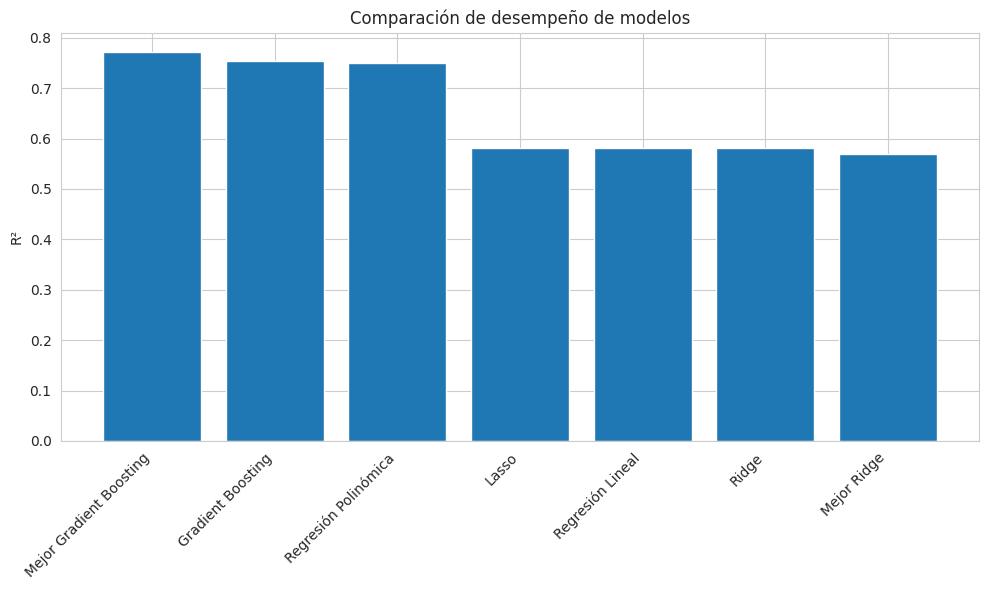

In [35]:
# =========================
# CELDA 34: VISUALIZACIÓN COMPARATIVA DE R²
# =========================

plt.figure(figsize=(10, 6))
plt.bar(df_resultados["Modelo"], df_resultados["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Comparación de desempeño de modelos")
plt.tight_layout()
plt.show()

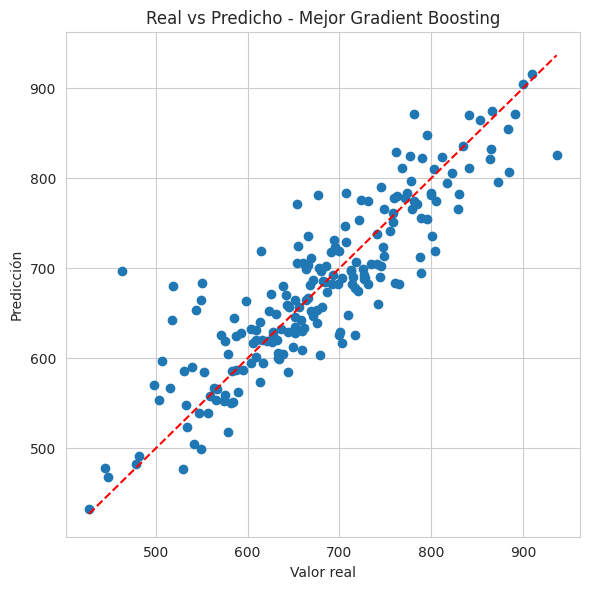

In [36]:
# =========================
# CELDA 35: REAL VS PREDICHO DEL MEJOR MODELO
# =========================

mejor_modelo_nombre = df_resultados.iloc[0]["Modelo"]

if mejor_modelo_nombre == "Mejor Gradient Boosting":
    y_pred_final = y_pred_mejor_gb
elif mejor_modelo_nombre == "Gradient Boosting":
    y_pred_final = y_pred_gb
elif mejor_modelo_nombre == "Mejor Ridge":
    y_pred_final = y_pred_mejor_ridge
elif mejor_modelo_nombre == "Ridge":
    y_pred_final = y_pred_ridge
elif mejor_modelo_nombre == "Lasso":
    y_pred_final = y_pred_lasso
elif mejor_modelo_nombre == "Regresión Polinómica":
    y_pred_final = y_pred_test_poly
else:
    y_pred_final = y_pred_test

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_final)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Real vs Predicho - {mejor_modelo_nombre}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.tight_layout()
plt.show()

In [37]:
# =========================
# CELDA 36: CONCLUSIÓN DEL MODELO FINAL
# =========================

print("Modelo final seleccionado:", mejor_modelo_nombre)
print("\nResumen de resultados:")
print(df_resultados)

print(f"""
Conclusión:
El modelo seleccionado fue '{mejor_modelo_nombre}', ya que obtuvo el mejor valor de R²
en el conjunto de prueba y mostró un equilibrio adecuado entre precisión y robustez.
Esto sugiere que es el modelo más confiable para estimar el gasto promedio de clientes
en el contexto del problema de negocio planteado.
""")

Modelo final seleccionado: Mejor Gradient Boosting

Resumen de resultados:
                    Modelo    MAE   RMSE      R2
0  Mejor Gradient Boosting  35.81  48.40  0.7711
1        Gradient Boosting  36.34  50.22  0.7536
2     Regresión Polinómica  36.55  50.58  0.7500
3                    Lasso  52.05  65.50  0.5808
4         Regresión Lineal  52.08  65.53  0.5803
5                    Ridge  52.10  65.55  0.5802
6              Mejor Ridge  52.99  66.37  0.5695

Conclusión:
El modelo seleccionado fue 'Mejor Gradient Boosting', ya que obtuvo el mejor valor de R²
en el conjunto de prueba y mostró un equilibrio adecuado entre precisión y robustez.
Esto sugiere que es el modelo más confiable para estimar el gasto promedio de clientes
en el contexto del problema de negocio planteado.



In [38]:
# =========================
# CELDA 37: CREAR CARPETA DE SALIDA
# =========================

import os

os.makedirs("outputs", exist_ok=True)

print("✅ Carpeta 'outputs' lista.")

✅ Carpeta 'outputs' lista.


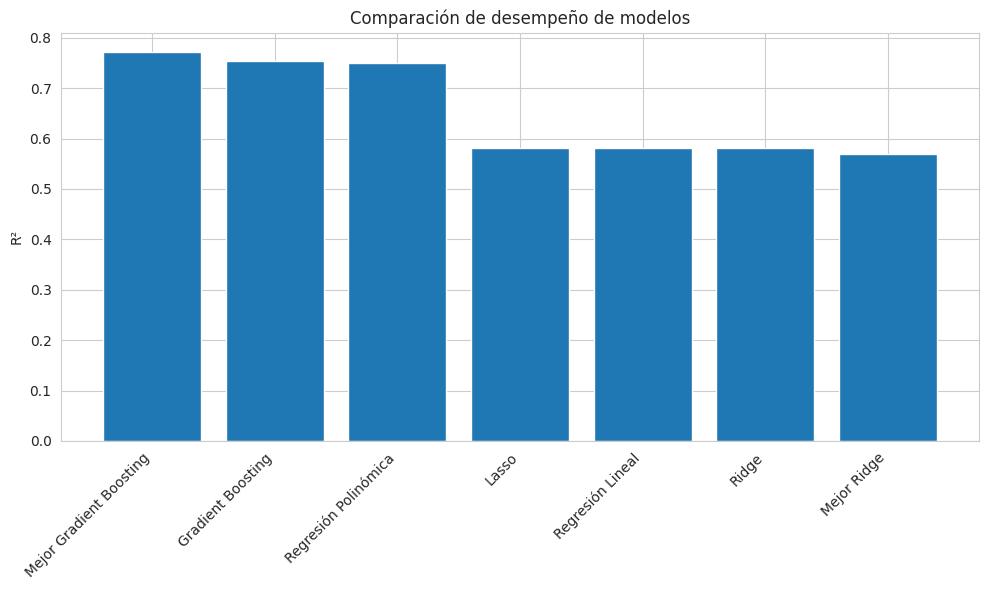

✅ Gráfico exportado en outputs/comparacion_modelos_r2.png


In [39]:
# =========================
# CELDA 38: EXPORTAR GRÁFICO COMPARATIVO
# =========================

plt.figure(figsize=(10, 6))
plt.bar(df_resultados["Modelo"], df_resultados["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Comparación de desempeño de modelos")
plt.tight_layout()
plt.savefig("outputs/comparacion_modelos_r2.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Gráfico exportado en outputs/comparacion_modelos_r2.png")

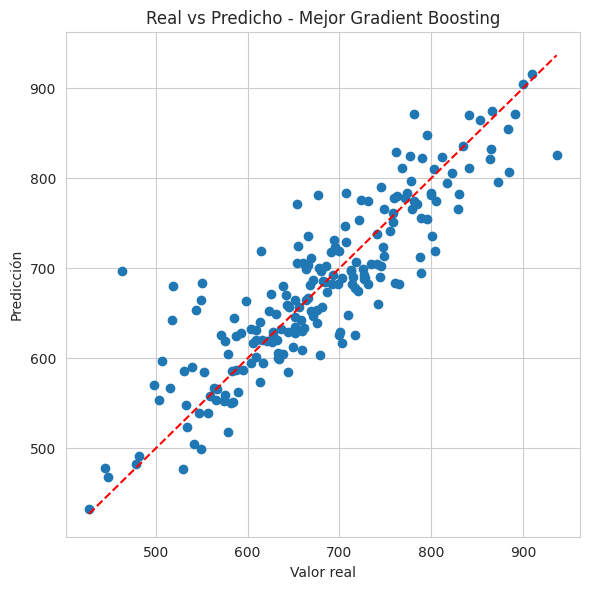

✅ Gráfico exportado en outputs/real_vs_predicho_mejor_modelo.png


In [40]:
# =========================
# CELDA 39: EXPORTAR GRÁFICO REAL VS PREDICHO
# =========================

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_final)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Real vs Predicho - {mejor_modelo_nombre}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.tight_layout()
plt.savefig("outputs/real_vs_predicho_mejor_modelo.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Gráfico exportado en outputs/real_vs_predicho_mejor_modelo.png")

In [41]:
# =========================
# CELDA 40: EXPORTAR TABLA DE RESULTADOS
# =========================

df_resultados.to_csv("outputs/resultados_modelos.csv", index=False)

print("✅ Tabla exportada en outputs/resultados_modelos.csv")
df_resultados

✅ Tabla exportada en outputs/resultados_modelos.csv


,Modelo,MAE,RMSE,R2
0,Mejor Gradient Boosting,35.81,48.40,0.7711
1,Gradient Boosting,36.34,50.22,0.7536
2,Regresión Polinómica,36.55,50.58,0.7500
3,Lasso,52.05,65.50,0.5808
4,Regresión Lineal,52.08,65.53,0.5803
5,Ridge,52.10,65.55,0.5802
6,Mejor Ridge,52.99,66.37,0.5695


In [42]:
# =========================
# CELDA 41: RESUMEN EJECUTIVO
# =========================

print("========== RESUMEN EJECUTIVO DEL PROYECTO ==========")
print(f"Cantidad de registros analizados: {df.shape[0]}")
print(f"Cantidad de variables predictoras: {X.shape[1]}")
print(f"Modelo final seleccionado: {mejor_modelo_nombre}")

mejor_fila = df_resultados.iloc[0]

print("\nMétricas del mejor modelo:")
print(f"MAE:  {mejor_fila['MAE']}")
print(f"RMSE: {mejor_fila['RMSE']}")
print(f"R²:   {mejor_fila['R2']}")

print("""
Interpretación:
El modelo final permite estimar el gasto promedio de clientes de e-commerce
a partir de variables demográficas y de comportamiento digital. Se compararon
múltiples enfoques de regresión y se seleccionó el más robusto según su
desempeño predictivo en el conjunto de prueba.
""")

========== RESUMEN EJECUTIVO DEL PROYECTO ==========
Cantidad de registros analizados: 1000
Cantidad de variables predictoras: 12
Modelo final seleccionado: Mejor Gradient Boosting

Métricas del mejor modelo:
MAE:  35.81
RMSE: 48.4
R²:   0.7711

Interpretación:
El modelo final permite estimar el gasto promedio de clientes de e-commerce
a partir de variables demográficas y de comportamiento digital. Se compararon
múltiples enfoques de regresión y se seleccionó el más robusto según su
desempeño predictivo en el conjunto de prueba.



In [43]:
# =========================
# CELDA 42: DESCARGA DE ARCHIVOS EN COLAB
# =========================

from google.colab import files

files.download("outputs/resultados_modelos.csv")
files.download("outputs/comparacion_modelos_r2.png")
files.download("outputs/real_vs_predicho_mejor_modelo.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
df_resultados

,Modelo,MAE,RMSE,R2
0,Mejor Gradient Boosting,35.81,48.40,0.7711
1,Gradient Boosting,36.34,50.22,0.7536
2,Regresión Polinómica,36.55,50.58,0.7500
3,Lasso,52.05,65.50,0.5808
4,Regresión Lineal,52.08,65.53,0.5803
5,Ridge,52.10,65.55,0.5802
6,Mejor Ridge,52.99,66.37,0.5695
